In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(1,)),

    tf.keras.layers.Dense(32, activation='tanh'),

    tf.keras.layers.Dense(32, activation='tanh'),

    tf.keras.layers.Dense(32, activation='tanh'),

    tf.keras.layers.Dense(2)

])

In [3]:
def loss_fn(model,t):
  with tf.GradientTape(persistent = True) as tape1, tf.GradientTape(persistent = True) as tape2:
    tape1.watch(t)
    tape2.watch(t)

    output = model(t)
    x = output[:,0:1]
    y = output[:,1:2]

    dx_dt = tape1.gradient(x,t)
    dy_dt = tape2.gradient(y,t)

  res_x = dx_dt + 2*x + y
  res_y = dy_dt + x + 2*y

  init_loss_x = tf.square(x[0] - 1)
  init_loss_y = tf.square(y[0] - 0)

  #del tape1,tape2

  loss = tf.reduce_mean(tf.square(res_x)) + tf.reduce_mean(tf.square(res_y)) + init_loss_x + init_loss_y

  return loss

In [4]:
def train(model, t, epochs, optimizer):

    for epoch in range(epochs):

        with tf.GradientTape() as tape:

            loss_value = loss_fn(model, t)

        grads = tape.gradient(loss_value,
                              model.trainable_variables)

        optimizer.apply_gradients(
            zip(grads, model.trainable_variables)
        )

        if epoch % 500 == 0:
            print(f'Epoch {epoch}: Loss = {loss_value.numpy()}')

In [5]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [6]:
t = tf.convert_to_tensor(np.linspace(0,5,100)[:,None],dtype=tf.float32)

In [7]:
train(model,t,2000,optimizer=optimizer)

Epoch 0: Loss = [8.034983]
Epoch 500: Loss = [0.02541064]
Epoch 1000: Loss = [0.00099539]
Epoch 1500: Loss = [0.00034946]


In [8]:
t_test = np.linspace(0,5,100)[:,None]
x_pred, y_pred = model(t_test).numpy().T

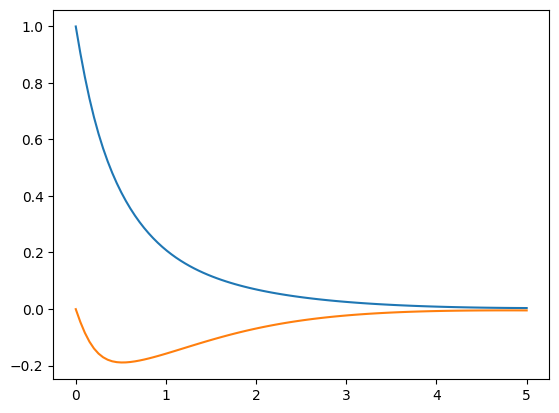

In [9]:
plt.plot(t_test,x_pred,label='x')
plt.plot(t_test,y_pred,label='y')


In [10]:
x_true = 0.5*np.exp(-t_test) + 0.5*np.exp(-3*t_test)
y_true = -0.5*np.exp(-t_test) + 0.5*np.exp(-3*t_test)

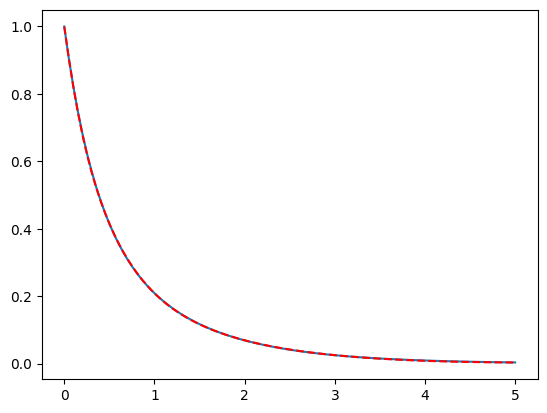

In [11]:
plt.plot(t_test,x_true,label='x')
plt.plot(t_test,x_pred,'r--')


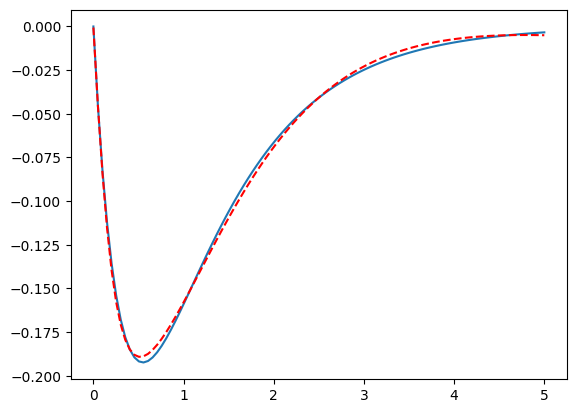

In [12]:
plt.plot(t_test,y_true,label='x')
plt.plot(t_test,y_pred,'r--')